In [2]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.set_num_threads(1)

In [3]:
data = load_breast_cancer()
X, y = data.data, data.target.astype(np.float32)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

Xh = torch.tensor(X_train, dtype=torch.float32)
yh = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
Xk = torch.tensor(X_val, dtype=torch.float32)
yk = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)

In [4]:
def tao_mang(so_dac_trung=30, an=128, seed=SEED, khoi_tao_0=False):
    torch.manual_seed(seed)
    mo = nn.Sequential(
        nn.Linear(so_dac_trung, an),
        nn.ReLU(),
        nn.Linear(an, 1),
    )
    if khoi_tao_0:
        for p in mo.parameters():
            nn.init.zeros_(p)
    return mo

In [5]:
def bce_tho(z, y):
    """Binary cross entropy viết theo kiểu hiển nhiên nhất, không chặn log(0)."""
    p = torch.sigmoid(z)
    return -(y * torch.log(p) + (1 - y) * torch.log(1 - p)).mean()

In [6]:
def huan_luyen(mo, lr=1e-3, so_vong=60, loss_fn=None,
               quen_zero_grad=False, optimizer_cls=torch.optim.Adam):
    if loss_fn is None:
        loss_fn = nn.BCEWithLogitsLoss()
    opt = optimizer_cls(mo.parameters(), lr=lr)
    lich_su = {"huan_luyen": [], "kiem_dinh": []}
    for vong in range(so_vong):
        mo.train()
        if not quen_zero_grad:
            opt.zero_grad()
        z = mo(Xh)
        loss = loss_fn(z, yh)
        loss.backward()
        opt.step()
 
        mo.eval()
        with torch.no_grad():
            zk = mo(Xk)
            loss_k = loss_fn(zk, yk)
 
        lich_su["huan_luyen"].append(loss.item())
        lich_su["kiem_dinh"].append(loss_k.item())
 
        if not torch.isfinite(loss):
            print(f"  -> {mo.__class__.__name__}: NaN/Inf o vong {vong}, "
                  f"|z|.max() = {z.abs().max().item():.4f}")
            break
    return lich_su

In [7]:
ket_qua = {}
 
# 1. Khoẻ mạnh — baseline
mo = tao_mang()
ket_qua["khoe_manh"] = huan_luyen(mo, lr=1e-3)
 
# 2. Tốc độ học quá lớn
mo = tao_mang()
ket_qua["lr_qua_lon"] = huan_luyen(mo, lr=10.0)
 
# 3. Tốc độ học quá nhỏ
mo = tao_mang()
ket_qua["lr_qua_nho"] = huan_luyen(mo, lr=1e-8)
 
# 4. Khởi tạo bằng 0
mo = tao_mang(khoi_tao_0=True)
ket_qua["khoi_tao_0"] = huan_luyen(mo, lr=1e-3)
 
# 5. Quá khớp — tăng sức chứa mạnh (30 -> 1024 -> 512 -> 1), không regularization
#    Cần nhiều vòng hơn (120) để khoảng cách huấn luyện/kiểm định lộ rõ
mo_lon = nn.Sequential(
    nn.Linear(30, 1024), nn.ReLU(),
    nn.Linear(1024, 512), nn.ReLU(),
    nn.Linear(512, 1),
)
ket_qua["qua_khop"] = huan_luyen(mo_lon, lr=1e-3, so_vong=120)
 
# 6. Quên zero_grad — dùng SGD thay Adam: Adam tự chuẩn hoá bước đi nên
#    che bớt hiệu ứng cộng dồn gradient; SGD lộ bệnh rõ và trung thực hơn
mo = tao_mang()
ket_qua["quen_zero_grad"] = huan_luyen(
    mo, lr=0.1, quen_zero_grad=True, optimizer_cls=torch.optim.SGD
)
 
# 7. Loss thành NaN — lr hơi cao + hàm loss tự viết không kẹp
mo = tao_mang()
ket_qua["loss_nan"] = huan_luyen(mo, lr=1e-2, loss_fn=bce_tho)

  -> Sequential: NaN/Inf o vong 13, |z|.max() = 26.1627


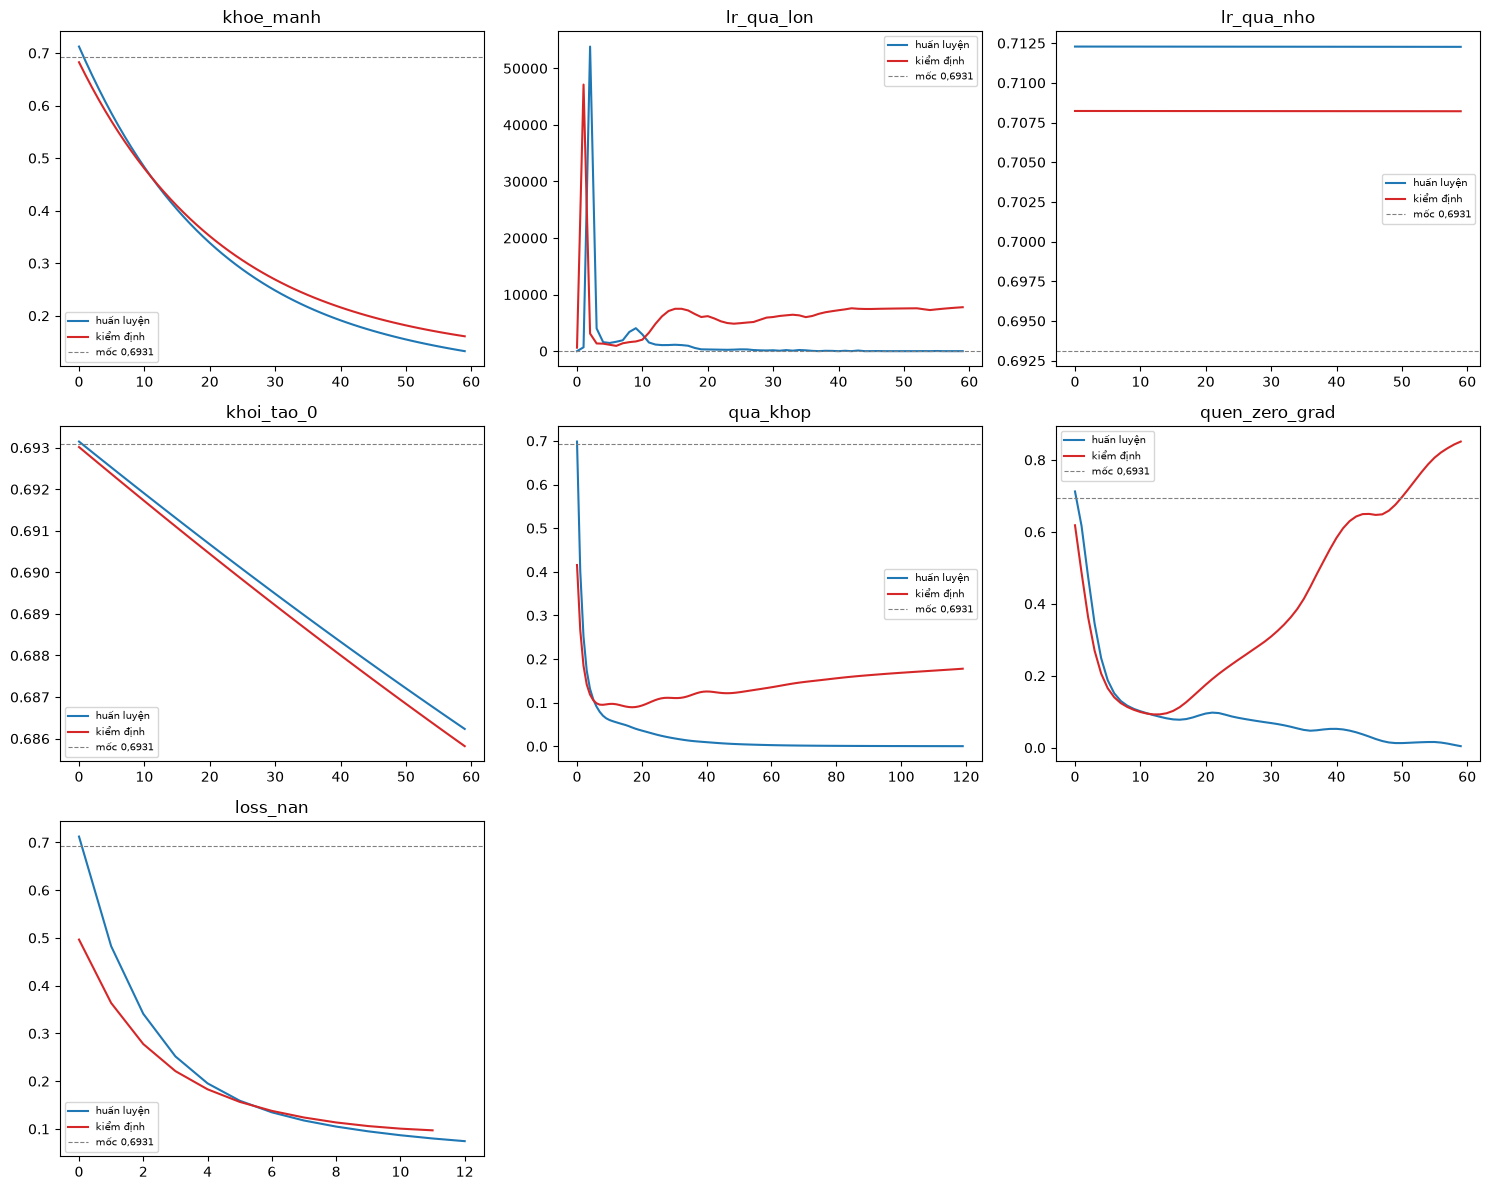

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()
for i, (ten, ls) in enumerate(ket_qua.items()):
    ax = axes[i]
    ax.plot(ls["huan_luyen"], label="huấn luyện", color="tab:blue")
    ax.plot(ls["kiem_dinh"], label="kiểm định", color="tab:red")
    ax.axhline(0.6931, color="gray", linestyle="--", linewidth=0.8, label="mốc 0,6931")
    ax.set_title(ten)
    ax.legend(fontsize=7)
for j in range(len(ket_qua), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig("bay_duong_cong.png", dpi=120)
plt.show()

In [9]:
print(f"{'ca benh':<18}{'hoc dau':>10}{'hoc cuoi':>10}{'kiem thap nhat':>16}{'kiem cuoi':>12}")
for ten, ls in ket_qua.items():
    hl, kd = ls["huan_luyen"], ls["kiem_dinh"]
    kiem_cuoi = kd[-1] if np.isfinite(kd[-1]) else float("nan")
    print(f"{ten:<18}{hl[0]:>10.4f}{hl[-1]:>10.4f}{min(kd):>16.4f}{kiem_cuoi:>12.4f}")

ca benh              hoc dau  hoc cuoi  kiem thap nhat   kiem cuoi
khoe_manh             0.7123    0.1327          0.1610      0.1610
lr_qua_lon            0.7123    0.0000        619.7750   7769.7183
lr_qua_nho            0.7123    0.7123          0.7082      0.7082
khoi_tao_0            0.6931    0.6862          0.6858      0.6858
qua_khop              0.6985    0.0004          0.0896      0.1779
quen_zero_grad        0.7123    0.0042          0.0925      0.8510
loss_nan              0.7123       nan          0.0971         nan
